# Quantum Kernel Advantage over Classical Collapse — reproduction (arXiv:2604.24597)

This notebook reproduces the paper's core phenomena on **substitute** foundation-model embeddings
(the real MIMIC-CXR embeddings are PhysioNet-gated) and adjudicates the headline claim.

**Claim under test:** an untuned QSVM beats an untuned linear SVM (C=1) on minority-class F1, because
the linear kernel "collapses" to majority prediction. **Our finding:** the gap is a decision-threshold
artifact — equal AUC — and a fair class-weighted linear SVM beats the QSVM.

In [11]:
import sys, numpy as np, pandas as pd
sys.path.insert(0, "../..")        # repo root (runtime_lib)
sys.path.insert(0, ".")           # project (lib)
from lib.quantum_kernel import fidelity_kernel, effective_rank
from lib.data import make_synthetic_embeddings
from lib.svm_pipeline import run_one
np.set_printoptions(precision=3, suppress=True)

## 1. The BSP fidelity kernel (CPU, exact)
K(x,y)=|⟨0|U†(x)U(y)|0⟩|² — PSD, unit diagonal.

In [12]:
rng = np.random.default_rng(0)
X_demo = rng.uniform(-1, 1, size=(6, 4))
K = fidelity_kernel(X_demo)              # bsp feature map
print("diag:", np.diag(K)); print("symmetric:", np.allclose(K, K.T))
print("min eigenvalue (PSD):", np.linalg.eigvalsh(K).min().round(6))
print("effective rank:", round(effective_rank(K), 3))

diag: [1. 1. 1. 1. 1. 1.]
symmetric: True
min eigenvalue (PSD): 0.421435
effective rank: 5.429


## 2. Substitute embeddings, weak-signal regime
`signal=0.25` is where the paper's *simultaneous* phenomenon appears: untuned linear collapses while
QSVM survives. (`signal=0` = insurance-from-X-ray is unpredictable → everything collapses.)

In [13]:
rows = []
for seed in range(3):
    X, y = make_synthetic_embeddings(n_samples=500, ambient_dim=256, signal=0.25, seed=seed)
    rows += run_one(X, y, q=8, seed=seed)
df = pd.DataFrame(rows)
summary = df.groupby("method")[["f1","auc","recall","eff_rank"]].mean().round(3)
summary["collapse_rate"] = df.assign(c=df.f1<0.05).groupby("method")["c"].mean().round(2)
summary.loc[["linear_c1","qsvm","rbf_rank_matched","linear_balanced","linear_tuned"]]

,f1,auc,recall,eff_rank,collapse_rate
method,,,,,
linear_c1,0.000,0.573,0.000,7.866,1.00
qsvm,0.044,0.599,0.024,31.755,0.67
rbf_rank_matched,0.089,0.595,0.048,31.751,0.33
linear_balanced,0.428,0.655,0.548,7.866,0.00
linear_tuned,0.418,0.657,0.548,7.866,0.00


**Read the table.** `linear_c1` collapses (F1≈0). `qsvm` survives (F1>0) — reproducing the paper.
But QSVM's **AUC ≈ linear_c1's AUC**: same discrimination, the F1 gap is just where the threshold lands.
And `linear_balanced` (one line of class weighting, no quantum) beats QSVM on both F1 and AUC.

## 3. The decisive picture: F1 separates, AUC does not

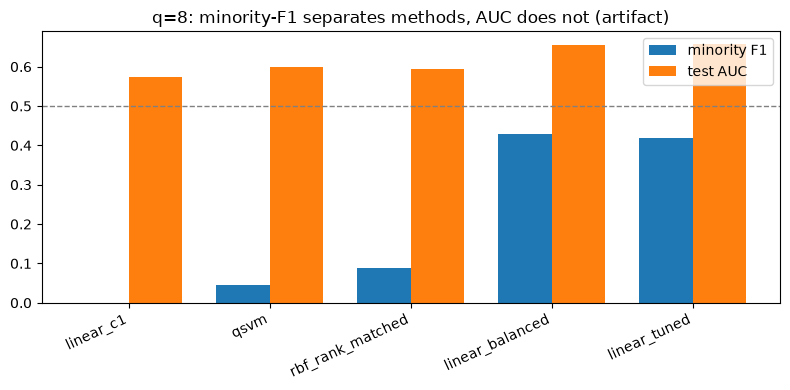

In [14]:
import matplotlib.pyplot as plt
order = ["linear_c1","qsvm","rbf_rank_matched","linear_balanced","linear_tuned"]
s = summary.loc[order]
x = np.arange(len(order)); w=0.38
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x-w/2, s["f1"], w, label="minority F1")
ax.bar(x+w/2, s["auc"], w, label="test AUC")
ax.axhline(0.5, ls="--", c="gray", lw=1)
ax.set_xticks(x); ax.set_xticklabels(order, rotation=25, ha="right")
ax.set_title("q=8: minority-F1 separates methods, AUC does not (artifact)"); ax.legend(); plt.tight_layout()
plt.show()

## 4. Photonic translation (MerLin 2-photon boson-sampling kernel)
Same behaviour, no AUC edge.

In [15]:
rows_p = []
for seed in range(2):
    X, y = make_synthetic_embeddings(n_samples=400, ambient_dim=256, signal=0.25, seed=seed)
    rows_p += run_one(X, y, q=6, seed=seed,
                      classifiers=["qsvm_photonic","linear_c1","linear_balanced"])
pd.DataFrame(rows_p).groupby("method")[["f1","auc","eff_rank"]].mean().round(3)

,f1,auc,eff_rank
method,,,
linear_balanced,0.517,0.726,5.914
linear_c1,0.000,0.371,5.914
qsvm_photonic,0.000,0.660,51.004


## 5. Interpretation
- **C1 (collapse), C2 (QSVM survives), C3 (eff_rank≫linear), C5 (concentration)** all reproduce.
- **C6 (added):** the advantage is a baseline-fairness + threshold artifact — equal AUC, and a fair
  class-weighted linear SVM wins. The photonic kernel inherits the same null result.

**Verdict: partially reproduced 🟠** — structural claims hold; the quantum-advantage interpretation does not.